In [4]:
import requests
import time
from IPython.display import Image, display

In [5]:
pugrest_prolog = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"
pugrest_input = "compound/cid/2244"
pugrest_operation = "property/MolecularFormula"
pugrest_output = "txt"

pugrest_url = "/".join( (pugrest_prolog, pugrest_input, pugrest_operation, pugrest_output) )
print("REQEST URL:", pugrest_url)

res = requests.get(pugrest_url)
print("OUTPUT    :", res.text.strip())

REQEST URL: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244/property/MolecularFormula/txt
OUTPUT    : C9H8O4


In [17]:
print(requests.get("https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv").text.strip())

"CID","MolecularWeight","HBondDonorCount","HBondAcceptorCount","HeavyAtomCount","XLogP","TPSA"
2244,180.16,1,4,13,1.200,63.6


1. Load the dataset into a Jupyter notebook using Pandas

In [18]:
url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv"

df = pd.read_csv(url)

2. Inspect the data: Check column names, data types, and handle any missing values.

In [19]:
df.head

<bound method NDFrame.head of     CID  MolecularWeight  HBondDonorCount  HBondAcceptorCount  HeavyAtomCount  \
0  2244           180.16                1                   4              13   

   XLogP  TPSA  
0    1.2  63.6  >

In [22]:
print(df.shape)
#get the number of rows and columns in dataset

(1, 7)


In [31]:
df.values

array([[2.2440e+03, 1.8016e+02, 1.0000e+00, 4.0000e+00, 1.3000e+01,
        1.2000e+00, 6.3600e+01]])

In [39]:
df.describe

<bound method NDFrame.describe of     CID  MolecularWeight  HBondDonorCount  HBondAcceptorCount  HeavyAtomCount  \
0  2244           180.16                1                   4              13   

   XLogP  TPSA  
0    1.2  63.6  >

Number of rows and columns,Column names,Data types of each column,Non-null (non-missing) counts per column,Memory usage

In [26]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CID                 1 non-null      int64  
 1   MolecularWeight     1 non-null      float64
 2   HBondDonorCount     1 non-null      int64  
 3   HBondAcceptorCount  1 non-null      int64  
 4   HeavyAtomCount      1 non-null      int64  
 5   XLogP               1 non-null      float64
 6   TPSA                1 non-null      float64
dtypes: float64(3), int64(4)
memory usage: 188.0 bytes


In [27]:
#handle any missing values
df.isnull().sum()

,0
CID,0
MolecularWeight,0
HBondDonorCount,0
HBondAcceptorCount,0
HeavyAtomCount,0
XLogP,0
TPSA,0


3. Perform basic data cleaning if needed.
    No missing values
    Find outliers

1. **Common Data Cleaning techniques**


1.   Find if there any null vaues present in the dataset using insull()
2.   Find Duplicates in dataset
3.   Rename Columns for Clarity names
4.   Convert Data Types if needed
5.  Check for Outliers  (use box plot for find the outliser and remve it using  
     IQR (Interquartile Range) Method or other techniuqes are there)




5. Visualize at least 2 property


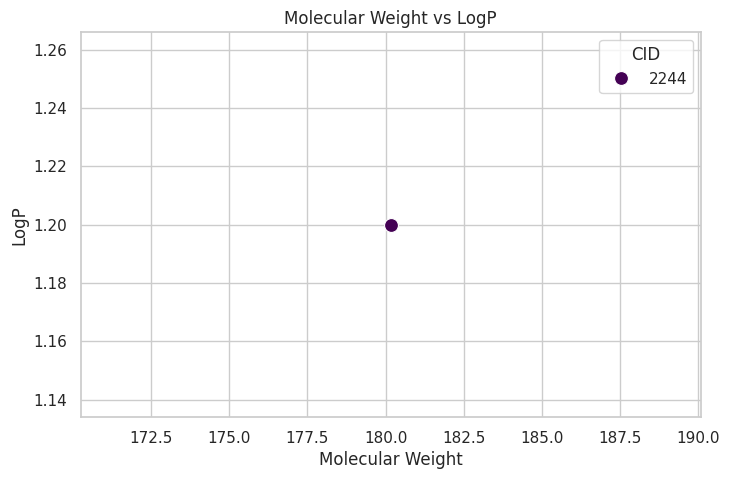

In [44]:

sns.set(style="whitegrid")

# Plot 1: Molecular Weight vs XLogP
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="MolecularWeight", y="XLogP", hue="CID", palette="viridis", s=100)
plt.title("Molecular Weight vs LogP")
plt.xlabel("Molecular Weight")
plt.ylabel("LogP")
plt.show()

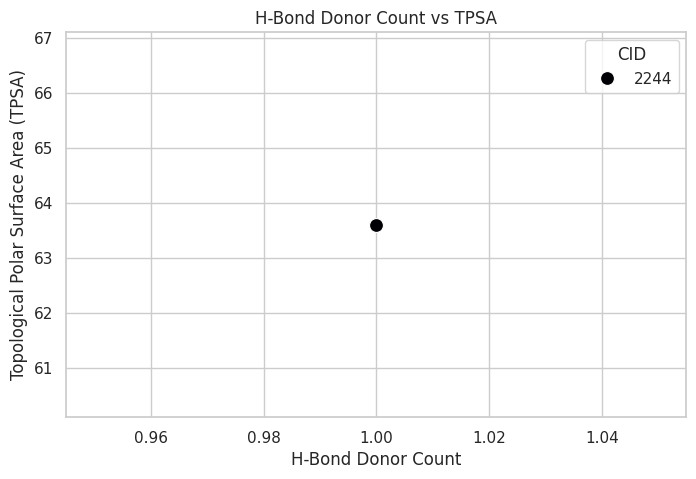

In [45]:
# Plot 2: HBondDonor vs TPSA
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="HBondDonorCount", y="TPSA", hue="CID", palette="magma", s=100)
plt.title("H-Bond Donor Count vs TPSA")
plt.xlabel("H-Bond Donor Count")
plt.ylabel("Topological Polar Surface Area (TPSA)")
plt.show()

6. Bonus (Optional): Explain how trends in these molecular properties can support solvent selection in drug development.

**Molecular Weight (MW)**:
Compounds with high molecular weight often have lower solubility in water and may require organic solvents (e.g., ethanol, DMSO) for formulation.
Lower MW drugs are more likely to be soluble in aqueous solvents, which are preferred for oral or intravenous delivery.

**XLogP (Partition Coefficient, LogP)**:
Indicates lipophilicity (how well the drug dissolves in fats vs. water).
  High LogP (>3) compounds are lipophilic, poorly soluble in water — thus,
  require non-polar solvents like hexane or ethyl acetate.

  Low LogP (< 1) indicates better water solubility, allowing aqueous solvents to be used.

**TPSA (Topological Polar Surface Area)**:
Reflects the drug’s ability to form hydrogen bonds, which influences absorption and permeability.
High TPSA (>140 Å²) suggests poor membrane permeability, and water solubility — needs polar solvents.
Low TPSA drugs are more lipophilic — suited for non-polar solvents.

**H-Bond Donor/Acceptor Count**:
Affects hydrogen bonding with the solvent.
Drugs with more H-bond donors/acceptors tend to favor hydrophilic solvents like water or methanol.
Fewer donors/acceptors suggest lipophilic behavior, requiring organic solvents.

**Heavy Atom Count:**
Generally correlates with MW and size.
Larger molecules may require solvents with higher solvating power due to steric hindrance.
